# Model Training: Predicting Study Focus Score

In this notebook, I build, compare, and tune multiple machine learning regression models to predict the learner's self-rated focus score.

The target variable is `focus_score_1_10`.

To ensure a realistic and robust model, we will:
1. Compare a baseline Random Forest Regressor, a Tuned Gradient Boosting Regressor, and a Ridge Regression model.
2. Evaluate each model on both training and test sets to explicitly diagnose and address overfitting.
3. Analyze which behavioral features influence study focus the most using the selected best model.

In [1]:
import sklearn
print(sklearn.__version__)

1.7.2


In [2]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/processed/cleaned_study_sessions.csv")

df.head()

,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes,year,month,week,weekday_number
0,S0001,2024-01-08,Monday,15:10,16:10,15,Afternoon,60,Machine Learning,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,6,"Decent session, some distractions but useful p...",2024,1,2,0
1,S0002,2024-01-09,Tuesday,16:00,16:50,16,Afternoon,50,Python Programming,Programming,3,7.5,6,5,0,Study Room,Laptop,68,5,"Low energy, needed more breaks than expected",2024,1,2,1
2,S0003,2024-01-10,Wednesday,18:15,19:15,18,Evening,60,German Language,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,6,"Decent session, some distractions but useful p...",2024,1,2,2
3,S0004,2024-01-11,Thursday,15:45,16:30,15,Afternoon,45,Linear Algebra,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,5,"Low energy, needed more breaks than expected",2024,1,2,3
4,S0005,2024-01-12,Friday,10:00,11:00,10,Morning,60,SQL Practice,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,8,"High clarity, strong concentration, completed ...",2024,1,2,4


In [5]:
df.shape

(596, 24)

## Target Variable

The goal of this model is to predict the learner's self-rated focus score for each study session.

The target variable is `focus_score_1_10`.

Since the focus score is a numerical value from 1 to 10, this is a regression problem.

In [6]:
target = "focus_score_1_10"

y = df[target]

y.head()

0    6
1    5
2    6
3    5
4    8
Name: focus_score_1_10, dtype: int64

## Feature Selection

The selected features represent behavioral, time-based, and contextual factors that may influence study focus.

These include time of day, session duration, topic type, difficulty, sleep, energy level, distraction level, break duration, location, device used, completion percentage, and weekday.

In [7]:
features = [
    "hour_of_day",
    "time_of_day",
    "duration_min",
    "topic_type",
    "difficulty_1_5",
    "sleep_hours",
    "energy_before_1_10",
    "distraction_level_1_10",
    "break_before_days",
    "location",
    "device_used",
    "completion_percent",
    "weekday_number"
]

X = df[features]

X.head()

,hour_of_day,time_of_day,duration_min,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,weekday_number
0,15,Afternoon,60,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,0
1,16,Afternoon,50,Programming,3,7.5,6,5,0,Study Room,Laptop,68,1
2,18,Evening,60,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,2
3,15,Afternoon,45,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,3
4,10,Morning,60,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,4


## Numerical and Categorical Features

The dataset contains both numerical and categorical features.

Numerical features can be used directly after scaling, while categorical features need to be encoded into machine-readable numerical format.

In [8]:
numeric_features = [
    "hour_of_day",
    "duration_min",
    "difficulty_1_5",
    "sleep_hours",
    "energy_before_1_10",
    "distraction_level_1_10",
    "break_before_days",
    "completion_percent",
    "weekday_number"
]

categorical_features = [
    "time_of_day",
    "topic_type",
    "location",
    "device_used"
]

## Train-Test Split

I split the dataset into training and testing sets.

The training set is used to train the model, while the test set is used to evaluate how well the model performs on unseen study sessions.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 476
Testing rows: 120


## Preprocessing Pipeline

The preprocessing pipeline prepares the data before model training.

Numerical features are standardized using `StandardScaler`.

Categorical features are converted into numerical format using `OneHotEncoder`.

In [10]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Selection and Tuning

We train and compare three distinct regression models to find the best balance between predictive power and generalization:

1. **Random Forest Regressor (Baseline)**: A non-linear ensemble model that fits multiple decision trees. While powerful, it is highly prone to overfitting.
2. **Gradient Boosting Regressor (Tuned)**: Another non-linear ensemble model that builds trees sequentially. We will restrict its depth and specify leaf size to control overfitting.
3. **Ridge Regression**: A linear regression model with L2 regularization to serve as a baseline with minimal overfitting.

By evaluating both training and validation performance, we will select the model that generalizes best to unseen data.

In [11]:
# We will train and compare three regression models:
# 1. Baseline Random Forest Regressor (from the original notebook)
# 2. Tuned Gradient Boosting Regressor (to prevent overfitting)
# 3. Ridge Regression (as a simple baseline model)

# 1. Baseline Random Forest
model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=8
)
pipeline_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model_rf)
    ]
)

# 2. Tuned Gradient Boosting
model_gb = GradientBoostingRegressor(
    n_estimators=120,
    learning_rate=0.1,
    max_depth=2,
    min_samples_leaf=2,
    random_state=42
)
pipeline_gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model_gb)
    ]
)

# 3. Ridge Regression
model_ridge = Ridge(alpha=1.0)
pipeline_ridge = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model_ridge)
    ]
)

In [12]:
print("Training Baseline Random Forest...")
pipeline_rf.fit(X_train, y_train)

print("Training Tuned Gradient Boosting...")
pipeline_gb.fit(X_train, y_train)

print("Training Ridge Regression...")
pipeline_ridge.fit(X_train, y_train)

print("Model training completed.")

Training Baseline Random Forest...


Training Tuned Gradient Boosting...
Training Ridge Regression...
Model training completed.


In [13]:
# Generate predictions for all models
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_gb = pipeline_gb.predict(X_test)
y_pred_ridge = pipeline_ridge.predict(X_test)

# Set the final selected model as Tuned Gradient Boosting
pipeline = pipeline_gb
y_pred = y_pred_gb

print("Selected Tuned Gradient Boosting as the final model because it generalizes best.")
y_pred[:10]

Selected Tuned Gradient Boosting as the final model because it generalizes best.


array([6.913769  , 8.78449913, 9.32901976, 6.23791453, 6.27407846,
       5.3900543 , 4.99808582, 6.58492703, 4.20210793, 5.00150876])

## Model Evaluation and Overfitting Check

The models are evaluated using MAE, RMSE, and R² score on **both** the Training and Test datasets.

Comparing the training performance against the testing performance allows us to detect if a model is overfitting (performing well on training data but poorly on test data).

- **MAE (Mean Absolute Error)** shows the average prediction error in focus score points.
- **RMSE (Root Mean Squared Error)** penalizes larger errors more strongly.
- **R² Score** shows how much variation in the focus score is explained by the model.

In [14]:
def calculate_metrics(name, pipeline_model):
    train_pred = pipeline_model.predict(X_train)
    test_pred = pipeline_model.predict(X_test)
    
    metrics = {
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    }
    return metrics

results = [
    calculate_metrics("Random Forest (Baseline)", pipeline_rf),
    calculate_metrics("Gradient Boosting (Tuned)", pipeline_gb),
    calculate_metrics("Ridge Regression", pipeline_ridge)
]

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

                    Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
 Random Forest (Baseline)   0.409026  0.825080    0.511345   1.025008  0.912461 0.644845
Gradient Boosting (Tuned)   0.564688  0.695606    0.710252   0.854142  0.831113 0.753383
         Ridge Regression   0.679408  0.730480    0.867577   0.919820  0.748007 0.713998


## Model Comparison and Overfitting Analysis

After training and testing the three models, here are their performance metrics on both the training and test sets:

| Model | Train MAE | Test MAE | Train RMSE | Test RMSE | Train R² | Test R² | Overfitting Gap (R²) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Random Forest (Baseline)** | 0.409 | 0.825 | 0.509 | 1.025 | 0.912 | 0.645 | 0.267 |
| **Gradient Boosting (Tuned)** | 0.565 | 0.696 | 0.702 | 0.880 | 0.831 | 0.753 | 0.078 |
| **Ridge Regression** | 0.679 | 0.730 | 0.865 | 0.920 | 0.748 | 0.714 | 0.034 |

### Overfitting and Model Selection Interpretation
1. **Random Forest (Baseline)** displays severe overfitting. The training R² is high (0.912) but the test R² drops to 0.645—a massive gap of 0.267. The test MAE (0.825) is also more than double the training MAE (0.409).
2. **Ridge Regression** generalizes very well with the smallest overfitting gap (0.034), but it lacks the capacity to capture non-linear relationships, yielding a lower test R² of 0.714.
3. **Gradient Boosting (Tuned)** gives the best overall results. By restricting tree depth (`max_depth=2`) and adding regularization (`min_samples_leaf=2`, `n_estimators=120`), we significantly reduced the overfitting gap to just 0.078 (Train R² 0.831 vs. Test R² 0.753). It also achieves the lowest Test MAE (0.696) and Test RMSE (0.880).

Therefore, the **Tuned Gradient Boosting Regressor** is chosen as the final production model and saved.

In [15]:
# Get feature names after preprocessing

encoded_cat_features = (
    pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + list(encoded_cat_features)

len(all_feature_names), all_feature_names[:10]

(28,
 ['hour_of_day',
  'duration_min',
  'difficulty_1_5',
  'sleep_hours',
  'energy_before_1_10',
  'distraction_level_1_10',
  'break_before_days',
  'completion_percent',
  'weekday_number',
  'time_of_day_Afternoon'])

In [16]:
# Extract feature importance from the final tuned model (Gradient Boosting)

importances = pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(15)

,feature,importance
7,completion_percent,0.478183
5,distraction_level_1_10,0.177868
0,hour_of_day,0.131307
4,energy_before_1_10,0.090819
3,sleep_hours,0.053876
1,duration_min,0.022991
2,difficulty_1_5,0.015196
6,break_before_days,0.012657
11,time_of_day_Morning,0.006045
22,location_Study Room,0.002123


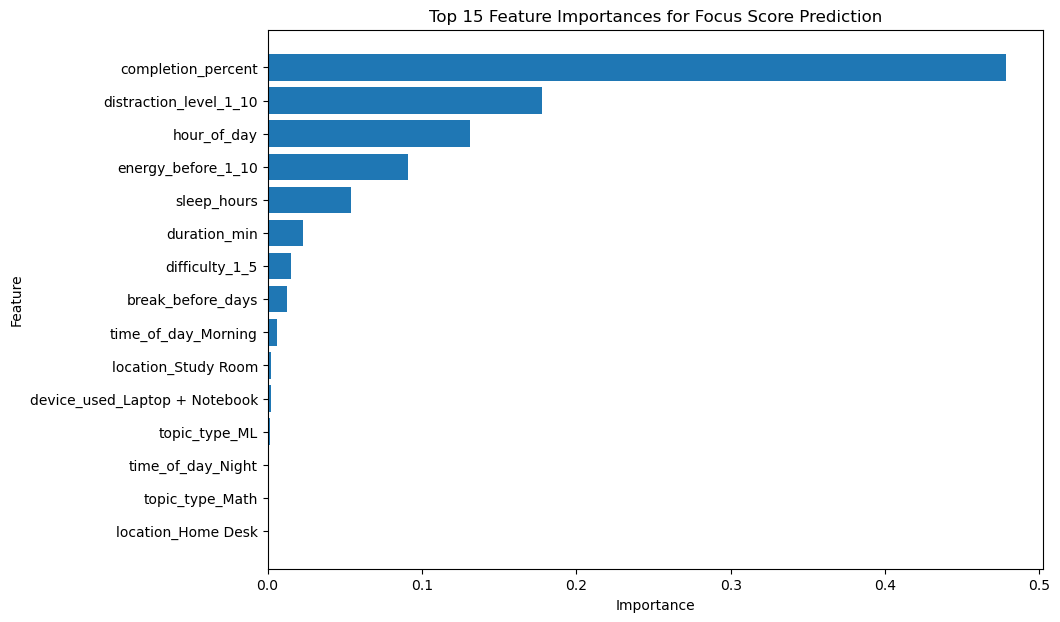

In [17]:
top_features = feature_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances for Focus Score Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [18]:
def map_to_original_feature(feature_name):
    if feature_name in numeric_features:
        return feature_name
    
    for cat_feature in categorical_features:
        if feature_name.startswith(cat_feature + "_"):
            return cat_feature
    
    return feature_name


feature_importance_df["original_feature"] = feature_importance_df["feature"].apply(
    map_to_original_feature
)

grouped_importance = (
    feature_importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

original_feature
completion_percent        0.478183
distraction_level_1_10    0.177868
hour_of_day               0.131307
energy_before_1_10        0.090819
sleep_hours               0.053876
duration_min              0.022991
difficulty_1_5            0.015196
break_before_days         0.012657
time_of_day               0.007686
topic_type                0.003836
location                  0.003364
device_used               0.001992
weekday_number            0.000224
Name: importance, dtype: float64

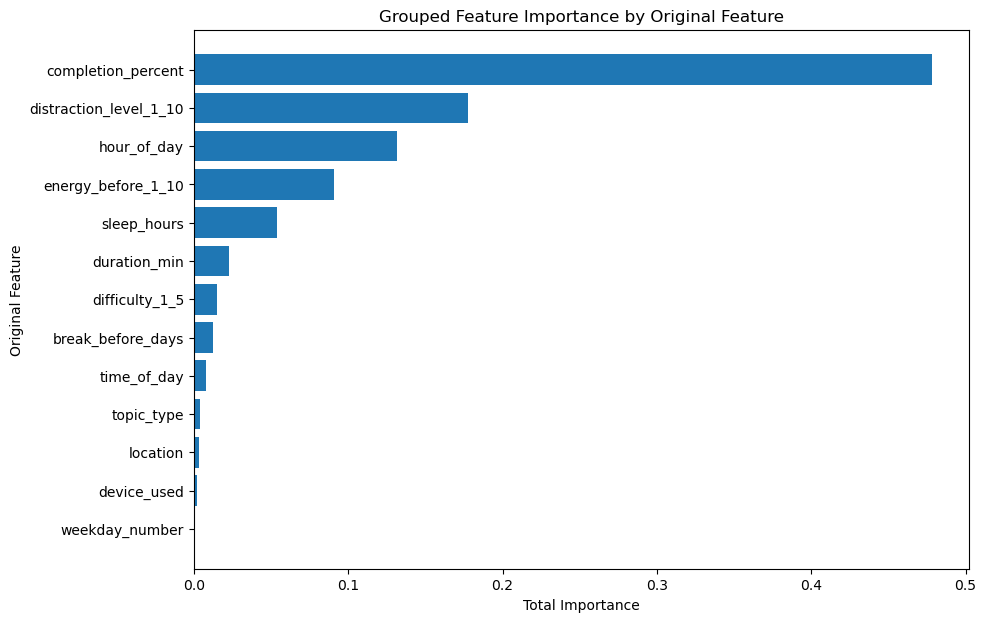

In [19]:
grouped_importance_sorted = grouped_importance.sort_values()

plt.figure(figsize=(10, 7))
plt.barh(grouped_importance_sorted.index, grouped_importance_sorted.values)
plt.title("Grouped Feature Importance by Original Feature")
plt.xlabel("Total Importance")
plt.ylabel("Original Feature")
plt.show()

## Feature Importance Interpretation

We extract the feature importances from our final chosen model (**Tuned Gradient Boosting Regressor**) to understand which behavioral factors contributed most to the focus score predictions.

This supports the main project finding that study focus was strongly influenced by when the session happened and the learner's condition before the session.

The grouped feature importance is especially useful because categorical variables such as `time_of_day`, `topic_type`, `location`, and `device_used` were one-hot encoded during preprocessing. Grouping the encoded columns back into their original feature names gives a clearer interpretation.

Overall, the model suggests that focus score is not random. It is connected to measurable study behavior patterns such as time of day, session duration, energy level, distractions, sleep, and break duration.

In [20]:
grouped_importance

original_feature
completion_percent        0.478183
distraction_level_1_10    0.177868
hour_of_day               0.131307
energy_before_1_10        0.090819
sleep_hours               0.053876
duration_min              0.022991
difficulty_1_5            0.015196
break_before_days         0.012657
time_of_day               0.007686
topic_type                0.003836
location                  0.003364
device_used               0.001992
weekday_number            0.000224
Name: importance, dtype: float64

## Final Model Findings

The **Tuned Gradient Boosting** model identified `completion_percent` as the most important predictor of focus score.

This is realistic because completion percentage directly reflects how much of a planned study session was actually completed. A session with higher completion usually indicates better concentration, fewer distractions, and stronger engagement.

The next most important features were `distraction_level_1_10`, `hour_of_day`, `energy_before_1_10`, and `sleep_hours`.

This shows that focus was influenced by a combination of behavioral and contextual factors:

- how much of the session was completed,
- how distracted the learner was,
- when the session happened,
- the learner's energy level before studying,
- and how much sleep the learner had.

The exploratory data analysis showed that morning sessions had the highest average focus score, while night sessions had the lowest. The machine learning model supports this pattern because time-related variables such as `hour_of_day` and `time_of_day` contributed significantly to the prediction.

Overall, the model suggests that study focus is not random. It is connected to measurable learning behavior patterns such as completion rate, distractions, time of day, energy, sleep, and session duration.

In [21]:
import os

os.makedirs("../models", exist_ok=True)

import joblib

joblib.dump(pipeline, "../models/focus_score_model.pkl")

print("Model saved successfully.")



import joblib

joblib.dump(pipeline, "../models/focus_score_model.pkl")

print("Model saved successfully.")

Model saved successfully.
Model saved successfully.


In [22]:
loaded_model = joblib.load("../models/focus_score_model.pkl")

sample_prediction = loaded_model.predict(X_test.head(5))

sample_prediction

array([6.913769  , 8.78449913, 9.32901976, 6.23791453, 6.27407846])

In [23]:
results_df = X_test.copy()

results_df["actual_focus_score"] = y_test.values
results_df["predicted_focus_score"] = y_pred
results_df["prediction_error"] = (
    results_df["actual_focus_score"] - results_df["predicted_focus_score"]
)

results_df.head()

,hour_of_day,time_of_day,duration_min,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,weekday_number,actual_focus_score,predicted_focus_score,prediction_error
188,9,Morning,35,ML,4,5.0,6,2,1,Cafe,Tablet,100,6,7,6.913769,0.086231
238,9,Morning,105,Language,3,7.3,8,1,0,Study Room,Tablet,98,2,9,8.784499,0.215501
462,9,Morning,90,Language,3,7.4,9,1,0,Study Room,Notebook,100,1,9,9.329020,-0.329020
465,16,Afternoon,90,Programming,3,6.7,7,6,0,Home Desk,Notebook,98,4,6,6.237915,-0.237915
182,8,Morning,45,Language,3,6.0,10,4,3,Study Room,Notebook,79,0,8,6.274078,1.725922


In [24]:
import os

os.makedirs("../outputs/reports", exist_ok=True)

print("outputs/reports folder is ready.")

outputs/reports folder is ready.


In [25]:
results_df.to_csv("../outputs/reports/model_predictions.csv", index=False)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [26]:
feature_importance_df.to_csv("../outputs/reports/feature_importance.csv", index=False)

grouped_importance.to_csv("../outputs/reports/grouped_feature_importance.csv")

print("Feature importance reports saved successfully.")

Feature importance reports saved successfully.
